# Entrenamiento 

In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from project.models_definitions.unet import build_film_unet_mnist
from project.loader import load
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from keras.callbacks import EarlyStopping

dataset = "mnist"

data = load.data(dataset=dataset)
x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]

x_test=data["x_test"]
y_test=data["y_test"]


x_train = np.array(x_train)
x_val   = np.array(x_val)
x_test   = np.array(x_test)


x_train = x_train.reshape(-1, 28, 28, 1)
x_val   = x_val.reshape(-1, 28, 28, 1)

model = build_film_unet_mnist()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse"
)

optimizer = tf.keras.optimizers.Adam()
model.compile(optimizer=optimizer)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)


# Shuffle targets
perm = np.random.permutation(len(x_train))
x_target = x_train[perm]
y_target = y_train[perm]


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    [x_train, y_target],
    x_target,
    epochs=100,
    batch_size=128,
    validation_data=val_dataset,
    callbacks=[early_stopping],
    verbose=1
    )




Usando mnist como dataset
Epoch 1/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 85s 191ms/step - loss: 0.0854 - val_loss: 0.0593
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0570 - val_loss: 0.0529
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0546 - val_loss: 0.0522
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0541 - val_loss: 0.0528
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0540 - val_loss: 0.0520
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0539 - val_loss: 0.0522
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0539 - val_loss: 0.0521
Epoch 8/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - loss: 0.0539 - val_loss: 0.0521
Epoch 9/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 210ms/step - loss: 0.0538 - val_loss: 0.0519
Epoch 10/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 210ms/step - loss: 0.0538 - val_loss: 0.0522
Epoch 11/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 90s 210ms/step - loss: 0.0538 -

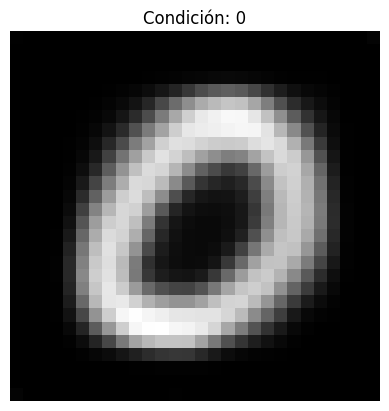

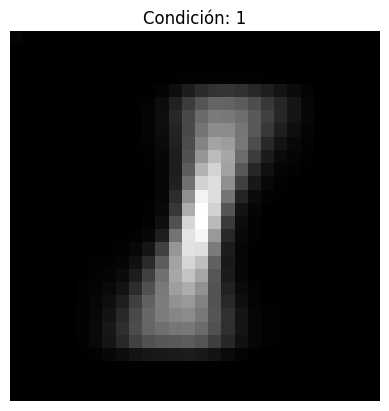

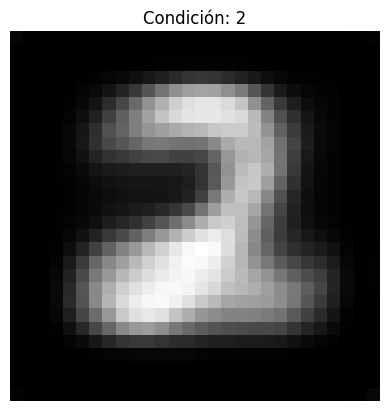

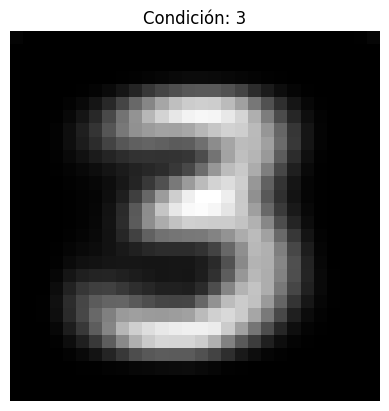

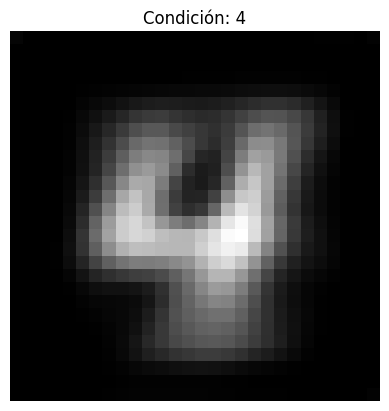

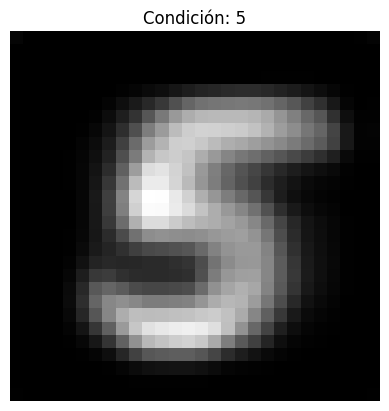

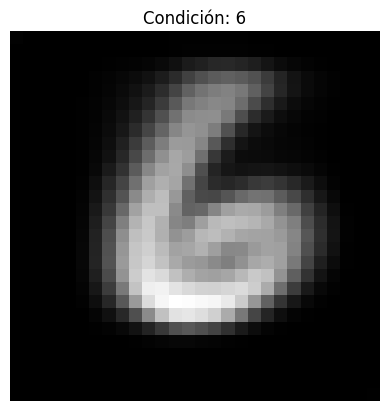

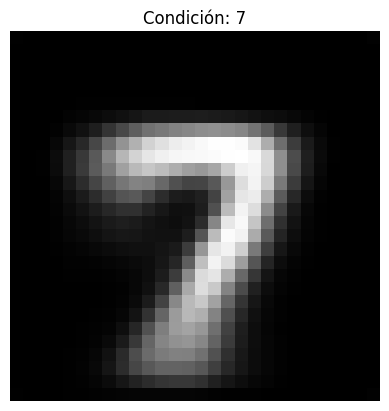

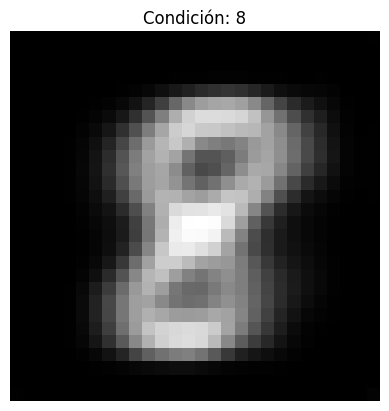

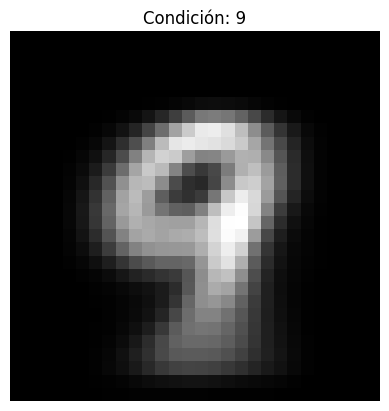

In [13]:
idx = 0
img = x_test[idx:idx+1]

for digit in range(10):
    cond = tf.one_hot([digit], 10)
    recon = model.predict([img, cond], verbose=0)

    plt.imshow(recon[0, :, :, 0], cmap="gray")
    plt.title(f"Condición: {digit}")
    plt.axis("off")
    plt.show()

Usando mnist como dataset
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


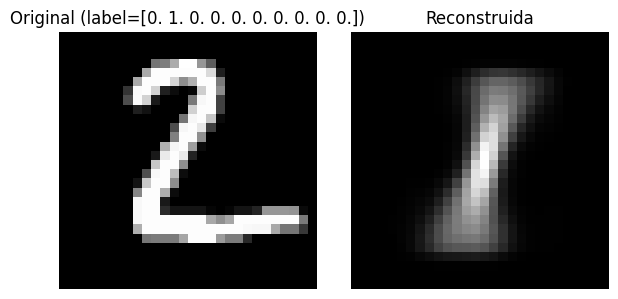

In [12]:
from project.loader import load
import matplotlib.pyplot as plt
import numpy as np

idx = 1  # puedes cambiarlo
dataset = "mnist"

data = load.data(dataset=dataset)
x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]

x_test=data["x_test"]
y_test=data["y_test"]


x_train = np.array(x_train)
x_val   = np.array(x_val)
x_test   = np.array(x_test)

x_train = x_train.reshape(-1, 28, 28, 1)
x_val   = x_val.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

img = x_test[idx:idx+1]          # shape (1, 28, 28, 1)
label = y_test[idx+1]              
print(label)
cond = np.expand_dims(label, axis=0)

reconstruction = model([img, cond], training=False)

plt.figure(figsize=(6, 3))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img[0, :, :, 0], cmap="gray")
plt.title(f"Original (label={label})")
plt.axis("off")

# Imagen reconstruida
plt.subplot(1, 2, 2)
plt.imshow(reconstruction[0, :, :, 0], cmap="gray")
plt.title("Reconstruida")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
recon_np = reconstruction.numpy()

print(
    recon_np.min(),
    recon_np.max(),
    recon_np.mean()
)


0.0 0.0 0.0


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_22[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_24[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      1,408 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 7, 7, 128) │    147,584 │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 128) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 7, 7, 128) │          0 │ conv2d_27[0][0],  │
│                     │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 14, 14,    │          0 │ add_2[0][0]       │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 14, 14,    │          0 │ up_sampling2d_4[… │
│ (Concatenate)       │ 192)              │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 14, 14,    │    110,656 │ concatenate_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_28[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_5     │ (None, 28, 28,    │          0 │ conv2d_29[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                 

 Total params: 1,417,157 (5.41 MB)

 Trainable params: 472,385 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 944,772 (3.60 MB)

In [3]:
print(reconstruction)

tf.Tensor(
[[[[0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0